# PART 1

## 1.1 Inspect the dataset

In [1]:
import pandas as pd
import sys

data = pd.read_csv('./data/ieee-cis-intro.csv')

In [2]:
print(data.head())

# No of rows : 50132
# No of columns : 56

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...   V1   V2   V3   V4   V5   V6   V7  \
0    NaN  150.0    discover  142.0  ...  1.0  1.0  1.0  1.0  1.0  1.0  1.0   
1  404.0  150.0  mastercard  102.0  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2  490.0  150.0        visa  166.0  ...  1.0  1.0  1.0  1.0  1.0  1.0  1.0   
3  567.0  150.0  mastercard  117.0  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

    V8   V9  V10  
0  1.0  1.0  0.0  
1  NaN  NaN  NaN  
2  1.0  1.0

In [3]:
print(data.columns)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'D1', 'D2',
       'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7',
       'V8', 'V9', 'V10'],
      dtype='str')


In [4]:
print(data.dtypes)

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
card1               int64
card2             float64
card3             float64
card4                 str
card5             float64
card6                 str
addr1             float64
addr2             float64
dist1             float64
dist2             float64
P_emaildomain         str
R_emaildomain         str
C1                  int64
C2                  int64
C3                  int64
C4                  int64
C5                  int64
C6                  int64
C7                  int64
C8                  int64
C9                  int64
C10                 int64
D1                  int64
D2                float64
D3                float64
D4                float64
D5                float64
D6                float64
D7                float64
D8                float64
D9                float64
D10               float64
M1                    str
M2          

In [5]:
print(data.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...   V1   V2   V3   V4   V5   V6   V7  \
0    NaN  150.0    discover  142.0  ...  1.0  1.0  1.0  1.0  1.0  1.0  1.0   
1  404.0  150.0  mastercard  102.0  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2  490.0  150.0        visa  166.0  ...  1.0  1.0  1.0  1.0  1.0  1.0  1.0   
3  567.0  150.0  mastercard  117.0  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

    V8   V9  V10  
0  1.0  1.0  0.0  
1  NaN  NaN  NaN  
2  1.0  1.0

## 1.2 Basic Data-Quality Check

In [6]:
print(data.isna().sum())

TransactionID         0
isFraud               0
TransactionDT         0
TransactionAmt        0
ProductCD             0
card1                 0
card2               701
card3                 3
card4                 6
card5               235
card6                 3
addr1              2591
addr2              2591
dist1             33199
dist2             46771
P_emaildomain      9011
R_emaildomain     38435
C1                    0
C2                    0
C3                    0
C4                    0
C5                    0
C6                    0
C7                    0
C8                    0
C9                    0
C10                   0
D1                    0
D2                26599
D3                25637
D4                23233
D5                32267
D6                45297
D7                47770
D8                41350
D9                41350
D10               12211
M1                32112
M2                32112
M3                32112
M4                27423
M5              

In [7]:
print(data.duplicated().sum())

0


## 1.3 Quick Orientation

1. The dataset contains card transaction information
2. fraud-rate lift would be useful.

# PART 2

## Category 1

### Q1. What is the overall observed fraud rate?

In [8]:
is_fraud = data[data['isFraud'] == 1]
print(is_fraud)
# 1357 transactions flagged as fraud

       TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
203          2987203        1          89760         445.000         W  18268   
240          2987240        1          90193          37.098         C  13413   
243          2987243        1          90246          37.098         C  13413   
245          2987245        1          90295          37.098         C  13413   
288          2987288        1          90986         155.521         C  16578   
...              ...      ...            ...             ...       ...    ...   
49664        3036664        1        1185567          40.693         C   5812   
49673        3036673        1        1185642          40.693         C   5812   
49756        3036756        1        1186619          40.693         C   3154   
49781        3036781        1        1186851         420.000         W   4030   
49870        3036870        1        1187827         200.000         R   6619   

       card2  card3        

In [9]:
not_fraud = data[data['isFraud'] == 0]
print(not_fraud)
# 48775 transactions not flagged as fraud

       TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0            2987000        0          86400           68.50         W  13926   
1            2987001        0          86401           29.00         W   2755   
2            2987002        0          86469           59.00         W   4663   
3            2987003        0          86499           50.00         W  18132   
4            2987004        0          86506           50.00         H   4497   
...              ...      ...            ...             ...       ...    ...   
50127        3037127        0        1190649           29.00         W  11162   
50128        3037128        0        1190653          154.95         W   2884   
50129        3037129        0        1190663           40.00         H  12582   
50130        3037130        0        1190693           50.00         H  15066   
50131        3037131        0        1190702           49.00         W   2755   

       card2  card3       c

In [10]:
global_fraud_rate = data['isFraud'].mean()
print(f"Fraud Rate: {global_fraud_rate:.4f}")  # e.g., 0.0350
print(f"Fraud Rate: {global_fraud_rate * 100:.2f}%")  # e.g., 3.50%

Fraud Rate: 0.0271
Fraud Rate: 2.71%


### Q2 How does transaction amount differ by fraud label?

In [11]:
transaction_amount = data.groupby('isFraud')['TransactionAmt'].describe()
print(transaction_amount)

           count        mean         std    min     25%    50%     75%  \
isFraud                                                                  
0        48775.0  127.648042  213.111579  1.251  42.180  67.95  119.95   
1         1357.0  145.793979  213.666941  0.292  41.327  81.97  171.00   

             max  
isFraud           
0        4829.95  
1        3081.97  


Noticeably, Transactions that have not been flagged as fraud generates a larger transaction amount.

## Category 2

### Q3. Does fraud differ across ProductCD?

* ProductCD = Product Code
* Web, Commercial, Hardware, Retail, Services

In [12]:
print(data['ProductCD'].head())

0    W
1    W
2    W
3    W
4    H
Name: ProductCD, dtype: str


In [13]:
summary_cd = (data.groupby('ProductCD')
                     .agg(
                         transaction_count = ('TransactionID', 'count'),
                         obs_fraud_rate = ('isFraud', 'mean')
                     )
                     .reset_index()
                     )
summary_cd

,ProductCD,transaction_count,obs_fraud_rate
0,C,4939,0.100628
1,H,7473,0.016325
2,R,3374,0.022525
3,S,1469,0.019741
4,W,32877,0.019254


In [14]:
summary_cd['fraud_rate_lift'] = summary_cd['obs_fraud_rate'] /global_fraud_rate

print(f'Overall Dataset Fraud Rate : {global_fraud_rate: .4%}\n')
print(summary_cd)

Overall Dataset Fraud Rate :  2.7069%

  ProductCD  transaction_count  obs_fraud_rate  fraud_rate_lift
0         C               4939        0.100628         3.717513
1         H               7473        0.016325         0.603115
2         R               3374        0.022525         0.832154
3         S               1469        0.019741         0.729309
4         W              32877        0.019254         0.711290


In [15]:
# Find row with max transaction count
most_common_pcd = summary_cd.loc[summary_cd['transaction_count'].idxmax(), 'ProductCD']

print(f'Most Common Product Code : {most_common_pcd}')

# Find row with highest obs_fraud_rate
highest_fr = summary_cd.loc[summary_cd['obs_fraud_rate'].idxmax(), 'ProductCD']

print(f'Highest Observed Fraud Rate : {highest_fr}')

Most Common Product Code : W
Highest Observed Fraud Rate : C


### Q4. Does fraud differ across card networks?

* c1 to c14 : counting/frequency features or velocity metrics
* represent counts of how many times a specific entity was observed across historical transaction window

In [16]:
summary_c4 = (data.groupby('card4')
              .agg(
                  transaction_count = ('TransactionID', 'count'),
                  obs_fraud_rate = ('isFraud', 'mean')
                  ).reset_index()
            )

summary_c4['fraud_rate_lift'] = summary_c4['obs_fraud_rate']/global_fraud_rate

summary_c4

,card4,transaction_count,obs_fraud_rate,fraud_rate_lift
0,american express,1092,0.017399,0.642786
1,discover,657,0.038052,1.405756
2,mastercard,15731,0.031784,1.174218
3,visa,32646,0.024842,0.917754


In [17]:
# Highest Obs Fraud Rate 
highest_obs_fr = summary_c4.loc[summary_c4['obs_fraud_rate'].idxmax(), 'card4']

print(f'Category with Highest Observed Fraud Rate : {highest_obs_fr}')

Category with Highest Observed Fraud Rate : discover


The Discover category has 657 observations, it may not be large enough to treat results confidently

## Category 3- Missingness and Time-Delta Features

### Q5. Can missingness itself be informative?

In [18]:
# Define which column we wish to test

col = "P_emaildomain"

# Create a binary indicator
status = data[col].isna().map({True: 'Missing', False : 'Present'})

# Group and calculating metrics
comparison = (data.groupby(status)
              .agg(
                  transaction_count = ('TransactionID', 'count'),
                  obs_fraud_rate = ('isFraud', 'mean')
              )
              .reset_index()
              .rename(columns = {col : "status"})
              )

comparison

,status,transaction_count,obs_fraud_rate
0,Missing,9011,0.023305
1,Present,41121,0.027893


In [19]:
# Computing the Lift

comparison['fraud_rate_lift'] = comparison['obs_fraud_rate']/global_fraud_rate

print(f'Overall fraud rate : {global_fraud_rate : .4%}\n')
print(comparison)

Overall fraud rate :  2.7069%

    status  transaction_count  obs_fraud_rate  fraud_rate_lift
0  Missing               9011        0.023305         0.860957
1  Present              41121        0.027893         1.030469


### Q6. Explore one D feature

* d1 to d15 : represents timedelta features
* measures the number of days elapsed between specific prior events and the current transaction timestamp 


In [20]:
choice_d = 'D1'

min_val = data[choice_d].min()
print(f'Minimum D1 Value is : {min_val}')

max_val = data[choice_d].max()
print(f'Maximum D1 Value is : {max_val}')

median = data[choice_d].median()
print(f'Median Value : {median}')

# Calculating Percentage Missing
missing = data[choice_d].isna().sum()
present = data[choice_d].notna().sum()
total_count = len(data)
percentage_missing = (missing/total_count)*100
print(f'Percentage Missing : {percentage_missing}')

# Comparison between isFraud values
comparison = data.groupby('isFraud')[choice_d].describe()
print(comparison)

Minimum D1 Value is : 0
Maximum D1 Value is : 636
Median Value : 0.0
Percentage Missing : 0.0
           count       mean         std  min  25%  50%    75%    max
isFraud                                                             
0        48775.0  82.461158  140.257863  0.0  0.0  0.0  106.0  636.0
1         1357.0  41.185704  100.604622  0.0  0.0  0.0   20.0  626.0


## Category 4 - Count and Engineered Features

### Q7. Explore one C feature

c1 to c14 columns are counting features
(e.g. How many times a particular payment card, email address, IP, or billing address was seen within a given time window)

In [21]:
choice_c = 'C1'

# Basic Distribution
print(f"=== Distribution Summary for {choice_c} ===")
print(data[choice_c].describe())

# Percentiles
percentiles = data[choice_c].quantile([0.5,0.75, 0.90, 0.95, 0.99, 0.999])
print(f"\n=== Percentiles for {choice_c} ===\n{percentiles}")

# Check for Skewness
skew_val = data[choice_c].skew()
print(f'Skewness of {choice_c} : {skew_val :.2f}')

# Breakdown across Fraud Labels 
print(f"\n=== Comparison Across Fraud Labels ===")
fraud_comparison = (
    data.groupby("isFraud")[choice_c]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        P75=lambda x: x.quantile(0.75),
        P95=lambda x: x.quantile(0.95),
        Max="max",
    )
    .reset_index()
)
fraud_comparison["isFraud"] = fraud_comparison["isFraud"].map(
    {0: "Legitimate (0)", 1: "Fraud (1)"}
)
print(fraud_comparison)


=== Distribution Summary for C1 ===
count    50132.000000
mean        26.318758
std        161.026509
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       1892.000000
Name: C1, dtype: float64

=== Percentiles for C1 ===
0.500       1.00
0.750       3.00
0.900       7.00
0.950      70.00
0.990     989.52
0.999    1830.00
Name: C1, dtype: float64
Skewness of C1 : 8.65

=== Comparison Across Fraud Labels ===
          isFraud  Count       Mean  Median         Std  P75    P95   Max
0  Legitimate (0)  48775  24.709749     1.0  154.357121  3.0   60.0  1892
1       Fraud (1)   1357  84.151805     2.0  313.314902  6.0  627.2  1872


### Q8. Explore the V features

* V columns are proprietary engineered features


=== Missing Percentage per V-feature ===
V1     69.37884
V2     69.37884
V3     69.37884
V4     69.37884
V5     69.37884
V6     69.37884
V7     69.37884
V8     69.37884
V9     69.37884
V10    69.37884
dtype: float64


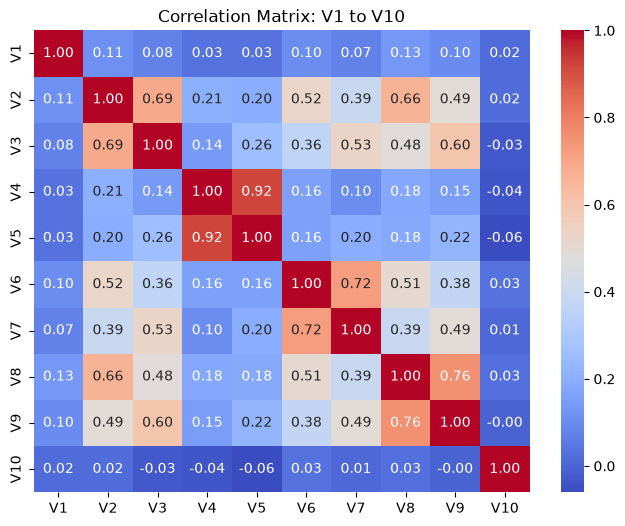

In [22]:
choice_v = 'V1'
v_cols = [f"V{i}" for i in range(1, 11)]

# Examining from V1 to V10 & relationship with isFraud
# Check correlation matrix
# Check for missing rates

# Missingness & Correlation Check
import matplotlib.pyplot as plt
import seaborn as sns
print("=== Missing Percentage per V-feature ===")
print(data[v_cols].isna().mean() * 100)

plt.figure(figsize=(8, 6))
sns.heatmap(data[v_cols].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix: V1 to V10")
plt.show()



In [23]:
# Distribution Comparison
v_summary = data.groupby("isFraud")[v_cols].agg(["mean", "median"]).T
print("\n=== Summary Stats by Fraud Status ===")
print(v_summary)


=== Summary Stats by Fraud Status ===
isFraud            0         1
V1  mean    0.999668  1.000000
    median  1.000000  1.000000
V2  mean    1.023945  1.014545
    median  1.000000  1.000000
V3  mean    1.047692  1.160000
    median  1.000000  1.000000
V4  mean    0.811289  0.872727
    median  1.000000  1.000000
V5  mean    0.839878  0.978182
    median  1.000000  1.000000
V6  mean    1.027262  1.014545
    median  1.000000  1.000000
V7  mean    1.048289  1.240000
    median  1.000000  1.000000
V8  mean    1.015455  1.014545
    median  1.000000  1.000000
V9  mean    1.027594  1.105455
    median  1.000000  1.000000
V10 mean    0.484147  0.192727
    median  0.000000  0.000000


#### COMMENTS : 

1) Missingness is Uniforma at ~ 69.38%

2) Collinearity in the Heatmap : 
* V4 and V5 correlate at 0.92
* V8 and V9 correlate at 0.76
* V6 and V7 correlate at 0.72
High correlation shares redundant signals i.e. do not need both if one is selected.

3) V10 has the strongest relative difference : with a mean of 0.484 and a drop in the fraud mean to 0.193


## Category 5 - Match Features and Interpretation

### Q9. Are match/mismatch states associated with fraud?

* M1 to M9 are mismatch verification flags
* True(T) : attributes matched (billing and shipping addresses match)
* Fase(F) : attributes are mismatched
* missing(NaN) : merchant or checkout did not collect the attribute

In [24]:
print(data['M5'].unique())


<StringArray>
['F', 'T', nan]
Length: 3, dtype: str


In [25]:
# In order to keep NaN, use groupby(..., dropna = False)
summary_m = (data.groupby('M5', dropna = False)
             .agg(
                 transaction_count = ('TransactionID', 'count'),
                 obs_fraud_rate = ('isFraud', 'mean')
             ).reset_index()
             )

summary_m['fraud_rate_lift'] = summary_m['obs_fraud_rate']/global_fraud_rate

summary_m


,M5,transaction_count,obs_fraud_rate,fraud_rate_lift
0,F,9778,0.020352,0.751862
1,T,8090,0.043511,1.607420
2,NaN,32264,0.024981,0.922894


COMMENTS : No, a mismatch does not automatically imply fraud

Matching Transactions (T) are more prone to fraud than mismatches (F).
For M5, mismatches show a lower fraud rate at 2.04% with a lift of 0.75, than matches with a 4.35% and lift of 1.61.

Absolute Fraud Rate : 4.35%
Legitimate Transaction in T : 100% - 4.35% = 95.65%
Over 95% of transactions across ALL states (T, F and NaN) are legitimate.


### Q10. Which baseline EDA result looks most interesting?

Condition: M5 == 'T' (Address/Verification Matched)

Count: 8,090 transactions

Observed Fraud Rate: 0.043511 (4.35%)

Fraud-Rate Lift: 1.607420 (1.61× baseline)

Reason to be Cautious:

Extreme Missingness & Selection Bias: Over 64% of all transactions (32,264 rows) have a missing M5 value, meaning this flag is only recorded for specific merchant checkout flows rather than the broader transaction population.

Base Rate Realities: Even with a high lift of 1.61, over 95.6% of matched transactions in this group are completely legitimate. Relying on this flag in isolation would produce massive false positive rates

# PART 3 - Verity a Fraud Fingerprint

## 3.1 State the candidate fingerprint

Transactions where the product code is Commercial (ProductCD == 'C'), the card has no prior history (D1 == 0) and the entity count indicates repeated velocity (C1 >= 2) will have a higher observation fraud rate than the dataset overall.

## 3.2 Test it


In [26]:
data['ProductCD'].unique()

<StringArray>
['W', 'H', 'C', 'S', 'R']
Length: 5, dtype: str

In [27]:
data['C2'].head()

0    1
1    1
2    1
3    5
4    1
Name: C2, dtype: int64

In [28]:
# Baseline Data
print(f'Global Fraud Rate : {global_fraud_rate}')
total_transactions = len(data)

# Defining our fingerprint conditions
fingerprint_mask = ((data['ProductCD'] == 'C') & (data['D1'] == 0) & (data['C1'] >= 2))

# Matched vs Unmatched comparison
fingerprint_data = data.assign(in_fingerprint = fingerprint_mask.map(
    {True : "Fingerprint Match", False: 'Other Transactions'}))
fingerprint_summary = (fingerprint_data
                       .groupby("in_fingerprint")
                       .agg(
                           transaction_count=("TransactionID", "count"),
                           observed_fraud_rate=("isFraud", "mean"),
                       )
                       .reset_index()
                       )

# Calc lift
fingerprint_summary["fraud_rate_lift"] = (
    fingerprint_summary["observed_fraud_rate"] / global_fraud_rate
)

print(f"Overall Baseline Fraud Rate: {global_fraud_rate:.4%}\n")
print(fingerprint_summary)

Global Fraud Rate : 0.02706853905688981
Overall Baseline Fraud Rate: 2.7069%

       in_fingerprint  transaction_count  observed_fraud_rate  fraud_rate_lift
0   Fingerprint Match               1677             0.155635         5.749666
1  Other Transactions              48455             0.022619         0.835617


## 3.3 Conclusion

Classification: Supported by this dataset

Explanation:
Transactions matching the fingerprint exhibit an observed fraud rate of 15.56%, representing a 5.75× lift over the baseline fraud rate of 2.71%.

Combining a high-risk digital/commercial channel (ProductCD == 'C') with a brand-new card/account registration (D1 == 0) and high transaction velocity (C1 >= 2) successfully isolates a high-density fraud cluster. With 1,677 matching observations, the sample size is sufficiently large to demonstrate a strong, non-trivial predictive signal.

## 3.4 Caveat

Why NOT a causal explanation?
Buying a digital item (ProductCD == 'C') on a new account (D1 == 0) does not turn someone into a fraudster.
The condition is just a symptom/correlation, not the root cause. 
Stolen credit cards are the cause; these numbers are just what the computer recorded.

Why NOT proof of a fraud attack?
Multiple completely different problems look identical under this condition.
A bot testing stolen credit cards looks the exact same in this data as a genuine fraudster buying digital gift cards. The rule only flags suspicious behavior, not who did it or how.


# PART 4 - Refute a Plausible Claim

#### **Claim** : "If customer information mismatches bank records (M5 == 'F'), the transaction is much more likely to be fraud/"

* What the data actually shows : In Q9, mismatched transactions (F) had a lower fraud rate (2.04%) with a lift of 0.75 than matched transactions (T) which had a fraud rate of 4.35% and a lift of 1.61.

* The data directly contradicts the intuitive assumption.

# PART 5 - Extend the Analysis

In [29]:
# Email domain asymmetry : legitimate purchaser provides their own email
# Check for fraud when the emails match.

# Ensure that emails match
both_emails = data[data['P_emaildomain'].notna() & data['R_emaildomain'].notna()]
matches = both_emails['P_emaildomain'] == both_emails['R_emaildomain']
both_emails['email_status'] = matches.map({True : "Same Domain (P == R)", False : "Different Domain (P != R)"})

email_match_summary = (both_emails
                       .groupby("email_status")
                       .agg(
                           transaction_count = ("TransactionID", 'count'),
                           obs_fraud_rate = ('isFraud', 'mean')
                       ).reset_index()
                       )

email_match_summary["fraud_rate_lift"] = (
    email_match_summary["obs_fraud_rate"] / global_fraud_rate
)
print(email_match_summary)

                email_status  transaction_count  obs_fraud_rate  \
0  Different Domain (P != R)               1640        0.013415   
1       Same Domain (P == R)               8667        0.071190   

   fraud_rate_lift  
0         0.495580  
1         2.629975  


Observation : 
By intuition, one might think that a match in Purchaser and Recipient Email Domain would mean a lower fraud rate.
However, it is clear that having P == R has a higher observed fraud rate with a 2.63 lift.

Caveat : 
Even though same domain (P == R) has a higher fraud rate and high lift, 92.88% of transactions in this group are completely legitimate.
If a production system uses this pattern to automatically decline or block transactions where (P == R), it would incorrectly block 93 legitimate customers for every 7 fraudsters caught.

Similarity with Lecture Fraud Pattern :
Consistent with : Card Testing/ Shared-Entity Fraud
Why : Fraudsters generating bulk accounts or scripted checkout runs often mass-produce throwaway emails on the same major domain (e.g., using @gmail.com for both sender and receiver fields in automated testing tools).


# PART 6 - Final Reflection

1) What is the strongest fraud-related pattern you found?
Transactions that involved Commercial/Digital products (ProductCD == 'C') combined with new accounts/card registration (D1 == 0) and an elevated count (C1 >=2 ). Intersecting columns concentrated the risk profile substantially more than any single feature in isolation.

2) What evidence makes it interesting?
The baseline fraud rate is 2.711%. With the mentioned conditions, the observed fraud rate jumpes to 15.56%, a 5.75x lift.
This captured 1677 transactions, about 3.35% of the total dataset.


3) What is the most important limitation or uncertainty?
Even at the 15.56% fraud rate, 84.44% of transactions in the group are legitimate customers.
Any automatic decline in this group causes ~5.4 false declines for every 1 fraudster stopped.

4) What would you investigate if you had access to the full dataset?
Check columns like DeviceInfo or IP addresses to see if all those repeat transactions (C1 >= 2) were actually coming from the exact same computer or Wi-Fi network.